In [1]:
import os
from pathlib import Path

print("CWD:", os.getcwd())
print("Files here:", os.listdir("."))


CWD: /home/raj123/lab_template
Files here: ['environment.yml', 'representations', 'occupancy_grid.ipynb', 'env_utils', '.ipynb_checkpoints', 'lab_instructions.pdf', 'Untitled.ipynb']


In [2]:
import sys
from pathlib import Path

repo_root = Path(".").resolve()
sys.path.append(str(repo_root))


In [3]:
import os
os.listdir("env_utils")



['src', 'setup.py']

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from env_utils import prepare_environment
from pathlib import Path


In [5]:
from env_utils import prepare_environment
from pathlib import Path

repo_root = Path(".").resolve()

SAMPLE_PATH = repo_root / "representations" / "data" / "demandaer_reading_5733.pkl"
CALIB_ROOT = repo_root / "representations" / "data" / "calib"
LANELET_MAP_PATH = repo_root / "representations" / "data" / "lanelet2_map.osm"

env = prepare_environment(
    sample_path=SAMPLE_PATH,
    calib_root=CALIB_ROOT,
    lanelet_map_path=LANELET_MAP_PATH,
    sensor_name="lidar_os1",
)

ego_xyz = env.ego_points[:, :3]


In [6]:
z_threshold = 0.2  # meters

ground_mask = ego_xyz[:, 2] < z_threshold
ground_points = ego_xyz[ground_mask]
obstacle_points = ego_xyz[~ground_mask]


In [7]:
# Grid parameters
resolution = 0.2  # meters per cell
x_min, x_max = -50, 50
y_min, y_max = -50, 50

grid_width  = int((x_max - x_min) / resolution)
grid_height = int((y_max - y_min) / resolution)

occupancy_grid = np.zeros((grid_height, grid_width), dtype=np.uint8)



In [8]:
for x, y, z in obstacle_points:
    ix = int((x - x_min) / resolution)
    iy = int((y - y_min) / resolution)

    if 0 <= ix < grid_width and 0 <= iy < grid_height:
        occupancy_grid[iy, ix] = 1


In [9]:
# Inflate obstacles for safety
from scipy.ndimage import binary_dilation

occupancy_grid = binary_dilation(occupancy_grid, iterations=2)


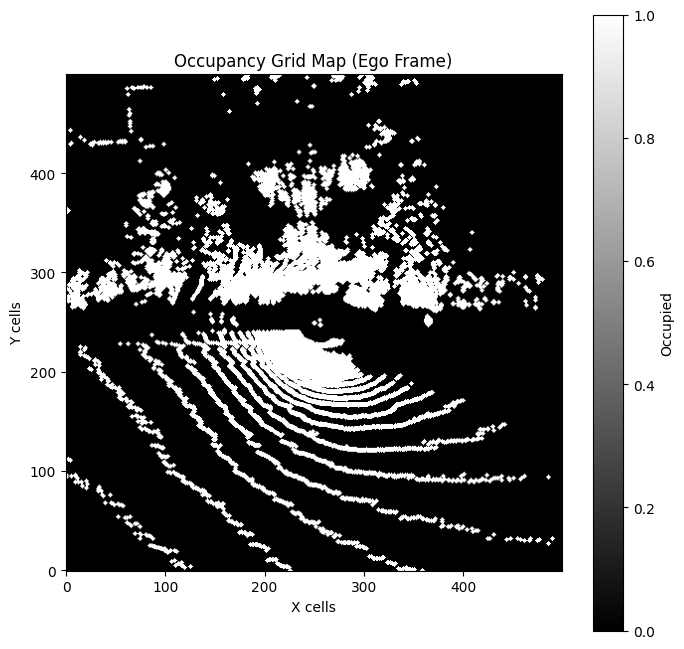

In [10]:
plt.figure(figsize=(8, 8))
plt.imshow(occupancy_grid, cmap="gray", origin="lower")
plt.title("Occupancy Grid Map (Ego Frame)")
plt.xlabel("X cells")
plt.ylabel("Y cells")
plt.colorbar(label="Occupied")
plt.show()
